# Relacion de los datos

 En este notebook nos interesa demostrar como se relacionan los datos del partido tal como la cantidad de goles esperada por partido(Xg), tiros(shots), tiros al arco(SoT) y posesion con el resultado final del partido.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import empiricaldist
import sqlite3
import scipy.stats
conn = sqlite3.connect("../data/Datos_Limpios.db")

## Xg y Goles

Empecemos con un test de correlacion entre los datos.
Las columnas home_xg y away_xg contienen los goles esperados de cada equipo en el desarrollo del partido. A su vez, home_score y away_score contienen los goles de cada equipo en el partido.
Si home_xg y away_xg se basan en el desarrollo del partido, deberia haber una buena correlacion entre estos y home_score y away_score.

En la base de datos, la tabla que contiene goles esperados por partido es world_cup_matches, la cual contiene datos sobre todos los partidos de mundiales hasta la fecha (mundial 2026).


In [3]:

query = """
SELECT * 
FROM world_cup_matches
"""

wcm = pd.read_sql_query(query, conn)
wcm

,match_id,date,home_team,home_team_id,away_team,away_team_id,round,home_score,away_score,neutral,...,away_penalty_score,home_xg,away_xg,home_possession,away_possession,home_sot,away_sot,home_shots,away_shots,result
0,1408,1930-07-13,United States,175,Belgium,17,Group stage,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
1,1409,1930-07-13,France,61,Mexico,110,Group stage,4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
2,1410,1930-07-14,Yugoslavia,144,Brazil,25,Group stage,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
3,1411,1930-07-14,Romania,139,Peru,134,Group stage,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
4,1412,1930-07-15,Argentina,7,France,61,Group stage,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,48061,2026-07-11,Norway,127,England,53,Quarter-finals,1,2,1,...,NaN,0.77,0.96,48.0,52.0,4.0,8.0,13.0,14.0,away team win
1064,48062,2026-07-14,France,61,Spain,155,Semi-finals,0,2,1,...,NaN,0.30,1.63,49.0,51.0,3.0,2.0,10.0,10.0,away team win
1065,48063,2026-07-15,England,53,Argentina,7,Semi-finals,1,2,1,...,NaN,0.54,1.80,36.0,64.0,2.0,5.0,5.0,15.0,away team win
1066,48064,2026-07-18,France,61,England,53,Third-place match,4,6,1,...,NaN,2.88,2.88,46.0,54.0,9.0,11.0,19.0,19.0,away team win


Por ejemplo, si queremos ver datos de los ultimos y primeros partidos, podriamos hacer:

In [4]:
pd.concat([wcm.head(), wcm.tail()])

,match_id,date,home_team,home_team_id,away_team,away_team_id,round,home_score,away_score,neutral,...,away_penalty_score,home_xg,away_xg,home_possession,away_possession,home_sot,away_sot,home_shots,away_shots,result
0,1408,1930-07-13,United States,175,Belgium,17,Group stage,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
1,1409,1930-07-13,France,61,Mexico,110,Group stage,4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
2,1410,1930-07-14,Yugoslavia,144,Brazil,25,Group stage,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
3,1411,1930-07-14,Romania,139,Peru,134,Group stage,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
4,1412,1930-07-15,Argentina,7,France,61,Group stage,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
1063,48061,2026-07-11,Norway,127,England,53,Quarter-finals,1,2,1,...,NaN,0.77,0.96,48.0,52.0,4.0,8.0,13.0,14.0,away team win
1064,48062,2026-07-14,France,61,Spain,155,Semi-finals,0,2,1,...,NaN,0.30,1.63,49.0,51.0,3.0,2.0,10.0,10.0,away team win
1065,48063,2026-07-15,England,53,Argentina,7,Semi-finals,1,2,1,...,NaN,0.54,1.80,36.0,64.0,2.0,5.0,5.0,15.0,away team win
1066,48064,2026-07-18,France,61,England,53,Third-place match,4,6,1,...,NaN,2.88,2.88,46.0,54.0,9.0,11.0,19.0,19.0,away team win
1067,48065,2026-07-19,Spain,155,Argentina,7,Final,1,0,1,...,NaN,1.42,0.88,65.0,35.0,12.0,0.0,20.0,2.0,home team win


Antes de hacer el test, deberiamos filtrar a todas las filas que efectivamente contienen home_xg y away_xg. Estas estadisticas se empezaron a registrar hace relativamente poco, por lo cual en la gran mayoria de partidos este dato simplemente esta asignado como valor NaN.  
Asi que para hacer el analisis, deberiamos trabajar con el conjunto de partidos que no tengan estas columnas como valores NaN.

In [6]:

columns = ["home_xg", "away_xg"]
wcm_valido = wcm.dropna(subset=columns)

np.min(wcm_valido["date"]), np.max(wcm_valido["date"])


('2018-06-14', '2026-07-19')

Notemos como el primer partido en el que se empezo a registrar la estadistica de goles esperado por partido fue en 2018, y de ahi en adelante todos los partidos lo han registrado. Tambien, para hacer el test, unifiquemos todas las estadisticas separadas por equipo local (home team) y equipo visitante (away team).

In [7]:
xg = pd.concat([
    wcm_valido["home_xg"],
    wcm_valido["away_xg"]
], ignore_index=True)

goles = pd.concat([
    wcm_valido["home_score"],
    wcm_valido["away_score"]
], ignore_index=True)

In [8]:
len(xg), len(goles)

(464, 464)

Cabe aclarar que al hacer esto, podriamos perder una parte de la independencia de las observaciones, por que cada partido aportaria ahora dos datos de xg y dos datos de goles.

### Visualizando de los datos



Antes de hacer correlacion, veamos como se ve la distribucion de estas series. 
Para goals usemos una pmf (funcion de probabilidad) y un grafico de barras. 

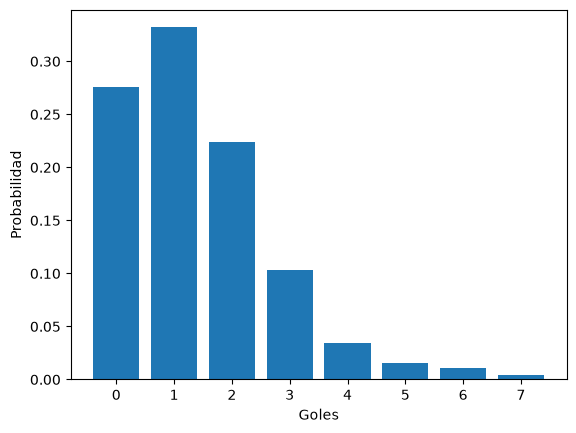

In [9]:
from empiricaldist import Pmf
from scipy.stats import gaussian_kde
goles_pmf = Pmf.from_seq(goles)
goles_pmf.bar()
plt.xlabel("Goles")
plt.ylabel("Probabilidad")
plt.show()

Como xg es continua, utilicemos una KDE para graficar su funcion de densidad de masa. Creamos aprox 200 valores que representen la probabilidad de la distribucion y graficamos.

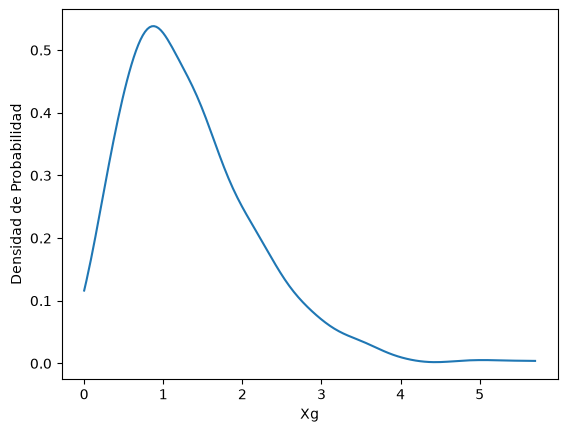

In [10]:
xg_kde = gaussian_kde(xg)
x = np.linspace(xg.min(), xg.max(), 201)
y = xg_kde(x)
plt.plot(x, y)
plt.xlabel("Xg")
plt.ylabel("Densidad de Probabilidad")
plt.show()

Parecen seguir una forma parecida, ahora si, calculemos su correlacion y veamos el scatter plot

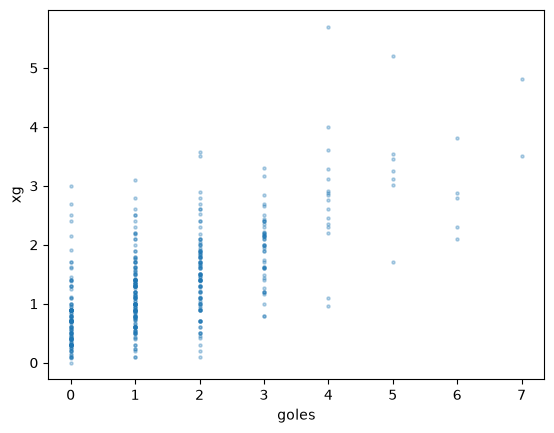

In [11]:
plt.scatter(goles, xg, s=5, alpha=0.3)
plt.ylabel("xg")
plt.xlabel("goles")
plt.show()

Como goles es una variable discreta con valores enteros, en el scatter plot esta va a ser representada en columnas.  
Aun asi, podemos identificar la tendencia, mientras mayor sea xg, mayor tiende a ser la cantidad de goles. El coeficiente de correlacion de estas dos variables es:

In [12]:
correlacion_observada = np.corrcoef(xg, goles)[0, 1]
correlacion_observada

np.float64(0.6808596566273841)

### Analizando la correlacion


Finalmente, verifiquemos si esta correlacion puede darse por chance, o es estadisticamente significativa:  
La hipotesis nula es que no hay correlacion entre goals y xg, por lo cual bajo esta condicion, si mezclamos los valores de estas series(permutacion) y volvemos a comparar su correlacion, la probabilidad de que esta de 0.68 no deberia ser muy baja.

-La primera siguiente funcion aplica permutacion.  
-La segunda calcula el valor absoluto de una correlacion (por que es igual de probable que su correlacion con este metodo varie para arriba como para abajo).  
-La tercera simula una pmf de una serie de datos continua.  
-La cuarta calcula valor p.

In [13]:
def permute(data):
    xs, ys = data
    new_xs = xs.values.copy()
    np.random.shuffle(new_xs)
    return new_xs, ys

def abs_correlation(data):
    xs, ys = data
    corr = np.corrcoef(xs, ys)[0, 1]
    return np.abs(corr)

def make_pmf(sample, low, high):
    kde = gaussian_kde(sample)
    qs = np.linspace(low, high, 201)
    ps = kde(qs)
    return Pmf(ps, qs)

def compute_p_value(simulated, observed):
    """Fraction of simulated values as big or bigger than the observed value."""
    return (np.asarray(simulated) >= observed).mean()

In [14]:
data = xg, goles
abs_correlation(permute(data)) 

np.float64(0.01505637130163884)

La correlacion absoluta tiende a rondar por 0.
veamos cual es el valor p de que la correlacion de los datos permutados de 0.68

(Text(0.5, 0, 'valor absoluto de la correlacion'),
 Text(0, 0.5, 'Densidad de probabilidad'))

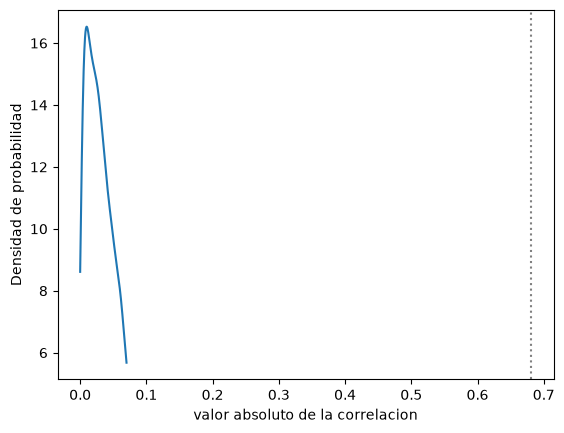

In [15]:
correlaciones_simuladas = [abs_correlation(permute(data)) for i in range(10001)]
pmf = make_pmf(correlaciones_simuladas, 0, 0.07)
pmf.plot()
plt.axvline(correlacion_observada, color="gray", ls=":")
plt.xlabel("valor absoluto de la correlacion"), plt.ylabel("Densidad de probabilidad")

In [16]:
valor_p = compute_p_value(correlaciones_simuladas, correlacion_observada)

por mas que la variable tenga valor 0, esto no implica que el valor p sea 0, solo significa que de las 10.000 simulaciones realizadas ningun alcanzo este valor, por lo cual el valor p real solo sabemos que es menor a 1 entre 10.000.
Aun asi podemos ver que la correlacion observada esta bastante mas lejos que la mas alta dentro de las simulaciones.  
Por lo cual podemos concluir que nuestra correlacion observada de 0.68 es estadisticamente significativa.


## Aplicacion en otros datos



Podemos generalizar este procedimiento para crear una funcion que para cualquier estadistica que se registre de los partidos de world_cup_matches, devuelva el valor p de su correlacion bajo la hipotesis nula de que esos datos no esten correlacionados.

In [17]:
def correlacion_y_valor_p(dato_x, dato_y):
    #Calcula el valor p de la correlacion de ambos datos,
    # bajo la hipotesis nula de que no esten correlacionados

    columns = [
        f"home_{dato_x}", f"away_{dato_x}",
        f"home_{dato_y}", f"away_{dato_y}"]
    valido = wcm.dropna(subset=columns)

    dato_x_completo = pd.concat([
        valido[f"home_{dato_x}"],
        valido[f"away_{dato_x}"]
    ], ignore_index=True)

    dato_y_completo = pd.concat([
            valido[f"home_{dato_y}"],
            valido[f"away_{dato_y}"]
        ], ignore_index=True)
    
    observada = np.corrcoef(dato_x_completo, dato_y_completo)[0, 1]

    data = dato_x_completo, dato_y_completo

    simulada = [abs_correlation(permute(data)) for i in range(10001)]

    valor_p = compute_p_value(simulada, abs(observada))
    #Le brindamos tambien el valor absoluto de la correlacion observada
    #Por que ya la estamos comparando al valor absoluto de la correlacion simulada

    return observada, valor_p

Comprobemos esta funcion con los resultados que ya sabemos

In [18]:
(correlacion_observada, valor_p) == correlacion_y_valor_p("score", "xg")

True

Algo que podemos ver es que, si calculamos la correlacion de la estadistica xg con otras como sot(shots on target, tiros al arco atajados o no por el arquero) o shots (tiro, independientemente de si fueron al arco). Es que estos datos estan altamente correlacionados.   
Lo cual tiene sentido por que la estadistica de goles esperados por partido se construye con la probabilidad de que cada tiro se convierta en gol, de 0.00 a 1.00.


In [19]:
correlacion_y_valor_p("xg", "sot"), correlacion_y_valor_p("xg", "shots")

((np.float64(0.6890542228538007), np.float64(0.0)),
 (np.float64(0.5935445234479383), np.float64(0.0)))

La correlacion de shots on target (sot) es mas alta que la de shots, porque la probabilidad de que un tiro que inicialmente iba al arco sea gol es mas alta que la de uno que no.  
Siguiendo, guardemos en un dataframe pandas cada estadistica relevante del partido su correlacion con el resultado del partido y si esta correlacion es estadisticamente significativa para visualizar mejor la relacion de estos datos:

In [20]:
correlaciones = pd.DataFrame(
    columns=["estadistica", "correlacion", "valor_p"]
)

for column in ["xg", "sot", "shots", "possession"]:
    correlacion, valor_p = correlacion_y_valor_p("score", column)
    correlaciones.loc[len(correlaciones)] = [
        column,
        correlacion,
        valor_p
    ]

In [21]:
correlaciones

,estadistica,correlacion,valor_p
0,xg,0.680860,0.0
1,sot,0.624512,0.0
2,shots,0.435121,0.0
3,possession,0.331269,0.0


Esto nos da evidencia de que la correlacion de estos datos con los goles es estadisticamente significativa, por lo cual nos podrian decir informacion sobre el resultado de este.  
Ademas, como su correlacion es positiva, podemos concluir tambien que los equipos que registran mas de estos datos tambien registran mas goles.

Ademas podemos interpretar con el valor de la correlacion que xg es el valor mas asociado al resultado en goles, seguido por sot, shots, y ultimo possession.

Esto nos da evidencia de que estas variables pueden ser utiles como variables predictoras.